# Кластеризация районов по показателям ЖКХ

## Цель исследования  
Сгруппировать районы по ключевым показателям ЖКХ и найти лучший кластер согласно критериям эффективности:

- **Оплата**
- **Долг**
- **Недопоставки**
- **Субсидии**

В конце определим лучший кластер и выберем в нём города-лидеры.

## Импорт библиотек

In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Загрузка данных

In [6]:
df = pd.read_csv("data.csv")
df.head(1)

,Район,Оплата,Долг,Недопоставки,Субсидии
0,Агрызский,0.83,2.05,0.093,1.35


## Подготовка данных

In [7]:
districts = df["Район"]
X = df.drop(columns=["Район"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Выбор оптимального числа кластеров (Метод локтя)

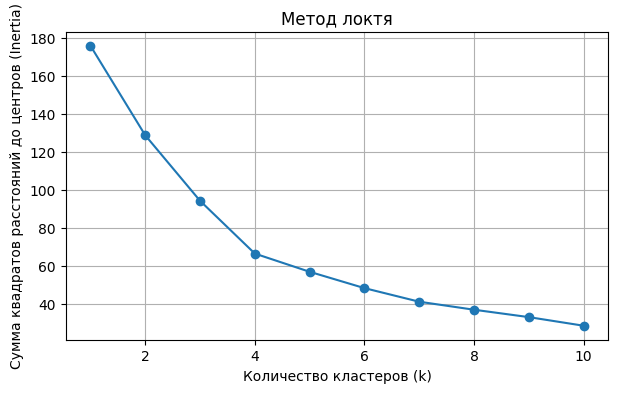

In [8]:
inertia_values = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(cluster_range, inertia_values, marker='o')
plt.title("Метод локтя")
plt.xlabel("Количество кластеров (k)")
plt.ylabel("Сумма квадратов расстояний до центров (Inertia)")
plt.grid(True)
plt.show()

По графику выбираем $k = 4$.

## Обучение модели K-Means и присвоение кластеров

In [9]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

df["cluster"] = kmeans.labels_
df.head(1)

,Район,Оплата,Долг,Недопоставки,Субсидии,cluster
0,Агрызский,0.83,2.05,0.093,1.35,2


## Статистика кластеров (медианные значения)

In [10]:
df.groupby("cluster").median(numeric_only=True)

,Оплата,Долг,Недопоставки,Субсидии
cluster,,,,
0,0.895,2.63,0.0021,0.845
1,0.740,5.80,0.1553,1.080
2,0.970,2.12,0.0041,1.520
3,0.285,4.03,0.0000,0.805


## Анализ «лучшего» кластера
Предположим, что кластер №2 показывает наиболее сбалансированные показатели.
Найдём лидеров по отдельным параметрам внутри него.

- Лидер по оплате

In [11]:
df[df.cluster == 2].sort_values(by="Оплата", ascending=False).head(1)

,Район,Оплата,Долг,Недопоставки,Субсидии,cluster
4,Алексеевский,1.56,3.04,0.0005,1.48,2


- Лидер по субсидиям

In [12]:
df[df.cluster == 2].sort_values(by="Субсидии", ascending=False).head(1)

,Район,Оплата,Долг,Недопоставки,Субсидии,cluster
28,Муслюмовский,0.97,3.41,0.0041,1.91,2


- Минимальные недопоставки

In [13]:
df[df.cluster == 2].sort_values(by="Недопоставки", ascending=True).head(1)

,Район,Оплата,Долг,Недопоставки,Субсидии,cluster
8,Арский,1.0,1.84,0.0,1.58,2


- Минимальный долг

In [14]:
df[df.cluster == 2].sort_values(by="Долг", ascending=True).head(1)

,Район,Оплата,Долг,Недопоставки,Субсидии,cluster
27,Мензелинский,0.96,1.24,0.0,1.69,2


## Полный список районов в выбранном кластере

In [15]:
df[df.cluster == 2]

,Район,Оплата,Долг,Недопоставки,Субсидии,cluster
0,Агрызский,0.83,2.05,0.0930,1.35,2
3,Актанышский,1.05,3.22,0.0539,1.52,2
4,Алексеевский,1.56,3.04,0.0005,1.48,2
8,Арский,1.00,1.84,0.0000,1.58,2
11,Балтасинский,0.83,1.84,0.0071,1.34,2
13,Буинский,1.28,2.18,0.0020,1.63,2
25,Мамадышский,0.99,2.00,0.0001,1.87,2
26,Менделеевский,0.74,2.88,0.0090,1.41,2
27,Мензелинский,0.96,1.24,0.0000,1.69,2
28,Муслюмовский,0.97,3.41,0.0041,1.91,2
